# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

import urllib.request
import matplotlib.pyplot as plt
import MyFunctions as mf    

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv")

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [4]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
907,28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
910,23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
911,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


In [7]:
# Hacemos que nuestro índice sea el id
df.set_index("laptop_ID", inplace=True)

In [8]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [9]:
df_full = pd.read_csv("./data/laptops.csv", encoding='latin1')

In [10]:
df_copy = df.copy()

In [11]:
# Screen resolution
# Vemos que hay unas mismas caracterísitcas que se van repitiendo "Full HD", "IPS Panel", "Touchscreen"... (menos de 10)
# haremos una especie the one-hot encoding con estas características,
# creando una nueva columna para cada una de ellas, con un valor de 1 si la laptop tiene esa característica y 0 si no la tiene
# Tambien vemos que los últimos caracteres son la resolución en formato "ancho x alto",
# crearemos dos nuevas columnas, una para el ancho y otra para el alto, y eliminaremos la columna original de ScreenResolution
print(f"\n{df_full["ScreenResolution"].value_counts()}")

mf.screen_resolution_split(df_copy)


ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x1

In [12]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company         912 non-null    object 
 1   Product         912 non-null    object 
 2   TypeName        912 non-null    object 
 3   Inches          912 non-null    float64
 4   Cpu             912 non-null    object 
 5   Ram             912 non-null    object 
 6   Memory          912 non-null    object 
 7   Gpu             912 non-null    object 
 8   OpSys           912 non-null    object 
 9   Weight          912 non-null    object 
 10  Price_in_euros  912 non-null    float64
 11  Full HD         912 non-null    int64  
 12  IPS Panel       912 non-null    int64  
 13  Touchscreen     912 non-null    int64  
 14  4K Ultra HD     912 non-null    int64  
 15  Retina Display  912 non-null    int64  
 16  Quad HD+        912 non-null    int64  
 17  Screen_Width    912 non-null    int64 

In [13]:
# Ram
# Nos aseguramos que Las unidades son GB, y luego convertimos la columna a tipo numérico
print(f"\n{df_full["Ram"].value_counts()}")
print(f"\nValores sin GB:{df_copy[~df_copy['Ram'].str.contains('GB', na=False)]['Ram'].unique()}")

mf.replace_value(df_copy, "Ram", "GB", "", int)


Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

Valores sin GB:[]


In [14]:
df_copy["Ram_GB"].value_counts()

Ram_GB
8     434
4     267
16    136
6      24
2      20
12     19
32     10
64      1
24      1
Name: count, dtype: int64

In [15]:
# Weight
# Nos aseguramos que Las unidades son Kg, y luego convertimos la columna a tipo numérico
print(f"\n{df_full["Weight"].value_counts()}")
print(f"\nValores sin Kg:{df_copy[~df_copy['Weight'].str.contains('kg', na=False)]['Weight'].unique()}")

mf.replace_value(df_copy, "Weight", "kg", "", float)


Weight
2.2kg      121
2.1kg       58
2.4kg       44
2.3kg       41
2.5kg       38
          ... 
3.52kg       1
2.21kg       1
2.191kg      1
2.34kg       1
4.0kg        1
Name: count, Length: 179, dtype: int64

Valores sin Kg:[]


In [16]:
df_copy["Weight_kg"].value_counts()

Weight_kg
2.20    94
2.10    40
2.00    33
2.40    31
2.50    29
        ..
0.91     1
2.15     1
2.54     1
1.18     1
4.33     1
Name: count, Length: 158, dtype: int64

In [17]:
# Memory
# Vemos que tenemos estos tipos de memoria: SSD, HDD, Flash Storage, Hybrid
# haremos una especie the one-hot encoding con estas características,
# creando una nueva columna para cada una de ellas, con un valor de 1 si la laptop tiene esa característica y 0 si no la tiene
# Tambien vemos que a veces hay dos tipos de memoria separados por un "+", crearemos dos nuevas columnas, 
# una para cada tipo de memoria, y eliminaremos la columna original de Memory
print(f"\n{df_full["Memory"].value_counts()}")

print(f"\nValores sin GB o TB:{df_copy[~df_copy['Memory'].str.contains('GB|TB', na=False)]['Memory'].unique()}")

mf.memory_split(df_copy)



Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                      

In [18]:
# CPU
# Vemos que el valor de la columna empieza con el nombre del fabricante del procesador, 
# y acaba con la velocidad en GHz.
# El resto de información es el modelo del procesador, a mi entender no es relevante y lo obviamos
print(f"\n{df_full["Cpu"].value_counts()}")

print(f"\nValores sin GHz:{df_copy[~df_copy['Cpu'].str.contains('GHz', na=False)]['Cpu'].unique()}")

mf.cpu_split(df_copy)


Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

Valores sin GHz:[]


In [19]:
df_copy["Cpu_Brand"].value_counts()

Cpu_Brand
Intel    870
AMD       42
Name: count, dtype: int64

In [20]:
# GPU
# Vemos que el valor de la columna empieza con el nombre del fabricante.
# El resto de información es el modelo de la tarjeta gráfica, a mi entender no es relevante y lo obviamos
print(f"\n{df_full["Gpu"].value_counts()}")

mf.gpu_split(df_copy)


Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64


In [21]:
df_copy["Gpu_Brand"].value_counts()

Gpu_Brand
Intel     509
Nvidia    284
AMD       119
Name: count, dtype: int64

In [22]:
# Product
# Vemos hay muchos productos diferentes, por lo que no es útil para nuestro modelo, así que la eliminamos
print(f"\n{df_full["Product"].value_counts()}")


Product
XPS 13                                   30
Inspiron 3567                            29
250 G6                                   21
Vostro 3568                              19
Legion Y520-15IKBN                       19
                                         ..
ThinkPad L460                             1
V510-15IKB (i5-7200U/8GB/256GB/FHD/No     1
Rog GL502VS                               1
Rog GL553VE-FY052T                        1
17-ak001nv (A6-9220/4GB/500GB/Radeon      1
Name: count, Length: 618, dtype: int64


In [23]:
# No aporta valor
df_copy.drop("Product", axis=1, inplace=True)

In [24]:
# OpSys
# Vemos que hay pocos sistemas operativos diferentes.
# Trataremos más tarde las categóricas que nos quedan
print(f"\n{df_full["OpSys"].value_counts()}")


OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64


In [25]:
# Company
# Vemos que hay varias varias marcas diferentes, pero algunas de ellas tienen muy pocas muestras, 
# por lo que las agrupamos en "Other"
print(f"\n{df_full["Company"].value_counts()}")

mf.other_grouping(df_copy, "Company", 10)


Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64


In [26]:
df_copy["Company"].value_counts()

Company
Lenovo     202
Dell       197
HP         194
Asus       121
Acer        74
MSI         37
Other       36
Toshiba     34
Apple       17
Name: count, dtype: int64

In [27]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   TypeName          912 non-null    object 
 2   Inches            912 non-null    float64
 3   OpSys             912 non-null    object 
 4   Price_in_euros    912 non-null    float64
 5   Full HD           912 non-null    int64  
 6   IPS Panel         912 non-null    int64  
 7   Touchscreen       912 non-null    int64  
 8   4K Ultra HD       912 non-null    int64  
 9   Retina Display    912 non-null    int64  
 10  Quad HD+          912 non-null    int64  
 11  Screen_Width      912 non-null    int64  
 12  Screen_Height     912 non-null    int64  
 13  Ram_GB            912 non-null    int64  
 14  Weight_kg         912 non-null    float64
 15  SSD_GB            912 non-null    int64  
 16  HDD_GB            912 non-null    int64  
 17  

In [28]:
# Tratamiento de categóricas
# Company, TypeName y OpSys tienen muchas categorías diferentes, haremos un target encoding, 
# asignando a cada categoría el valor medio de la variable objetivo (Price_in_euros) para esa categoría.

# Target encoding para Company, TypeName y opSys
features_big_cat = ["Company", "TypeName", "OpSys"]

mf.target_encoding(df_copy, features_big_cat, "Price_in_euros")

In [29]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inches            912 non-null    float64
 1   Price_in_euros    912 non-null    float64
 2   Full HD           912 non-null    int64  
 3   IPS Panel         912 non-null    int64  
 4   Touchscreen       912 non-null    int64  
 5   4K Ultra HD       912 non-null    int64  
 6   Retina Display    912 non-null    int64  
 7   Quad HD+          912 non-null    int64  
 8   Screen_Width      912 non-null    int64  
 9   Screen_Height     912 non-null    int64  
 10  Ram_GB            912 non-null    int64  
 11  Weight_kg         912 non-null    float64
 12  SSD_GB            912 non-null    int64  
 13  HDD_GB            912 non-null    int64  
 14  Flash Storage_GB  912 non-null    int64  
 15  Hybrid_GB         912 non-null    int64  
 16  Cpu_Brand         912 non-null    object 
 17  

In [30]:
# Finalmente, nos quedan 2 columnas categóricas, GPU y CPU, que tienen pocas categorías diferentes, 
# por lo que haremos un one-hot encoding para estas columnas.
features_small_cat = ["Cpu_Brand", "Gpu_Brand"]

df_copy = mf.one_hot_encoding(df_copy, features_small_cat)

In [31]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inches            912 non-null    float64
 1   Price_in_euros    912 non-null    float64
 2   Full HD           912 non-null    int64  
 3   IPS Panel         912 non-null    int64  
 4   Touchscreen       912 non-null    int64  
 5   4K Ultra HD       912 non-null    int64  
 6   Retina Display    912 non-null    int64  
 7   Quad HD+          912 non-null    int64  
 8   Screen_Width      912 non-null    int64  
 9   Screen_Height     912 non-null    int64  
 10  Ram_GB            912 non-null    int64  
 11  Weight_kg         912 non-null    float64
 12  SSD_GB            912 non-null    int64  
 13  HDD_GB            912 non-null    int64  
 14  Flash Storage_GB  912 non-null    int64  
 15  Hybrid_GB         912 non-null    int64  
 16  Speed_GHz         912 non-null    float64
 17  

In [32]:
df_copy.to_csv("my_df.csv") #muy importante el index = False

Text(0.5, 0, 'Price in euros')

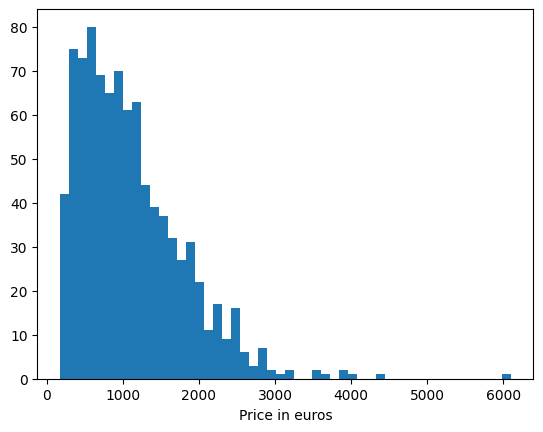

In [33]:
# Correlaciones, distribución de la variable objetivo, etc... 

# Distribución de la variable objetivo

plt.hist(df_copy["Price_in_euros"], bins=50)
plt.xlabel("Price in euros")


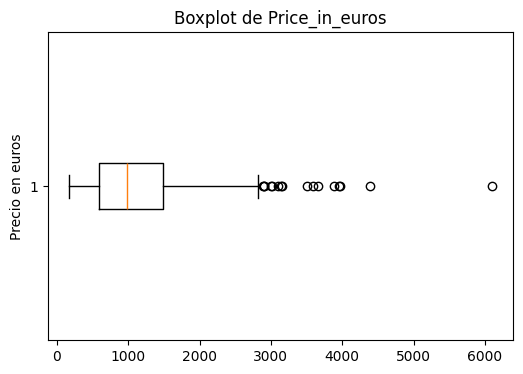

In [34]:
# Distribución de la variable objetivo

plt.figure(figsize=(6, 4))
plt.boxplot(df['Price_in_euros'], vert=False)
plt.title('Boxplot de Price_in_euros')
plt.ylabel('Precio en euros')
plt.show()


In [35]:
# Outliers en la variable objetivo
mf.outlier_iqr(df_copy, "Price_in_euros")


Outliers in Price_in_euros: 
    laptop_ID  Price_in_euros
0        1118         2899.00
1         787         2899.00
2         200         6099.00
3         731         3659.40
4         537         3012.77
5         302         2884.86
6         924         3100.00
7        1081         3975.00
8        1249         3499.00
9        1151         3949.40
10        243         3890.00
11        667         3147.37
12        570         2999.00
13        758         4389.00
14        982         3149.00
15        789         3588.80


In [36]:
# Hay varios outliers en la variable objetivo, 
# aplicaremos un logaritmo a la variable objetivo para reducir el impacto de estos outliers en nuestro modelo
df_copy["Price_in_euros"] = np.log(df_copy["Price_in_euros"])

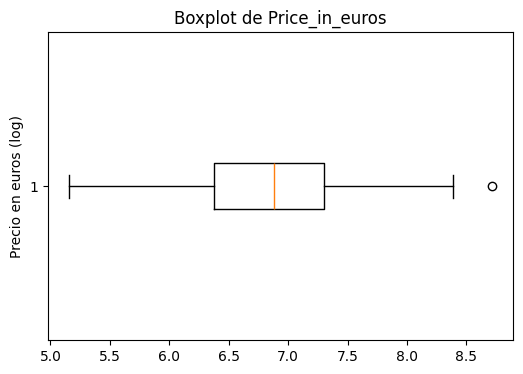

In [37]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_copy['Price_in_euros'], vert=False)
plt.title('Boxplot de Price_in_euros')
plt.ylabel('Precio en euros (log)')
plt.show()

In [38]:
# Outliers en la variable objetivo logaritmizada
mf.outlier_iqr(df_copy, "Price_in_euros")


Outliers in Price_in_euros: 
   laptop_ID  Price_in_euros
0        200         8.71588


In [39]:
# Correlaciones con la variable objetivo logaritmizada
correlations = df_copy.corr()["Price_in_euros"].sort_values(ascending=False)
print(correlations)

Price_in_euros      1.000000
Ram_GB              0.679431
SSD_GB              0.652279
TypeName_Encoded    0.642807
Screen_Height       0.560624
Screen_Width        0.559601
Speed_GHz           0.508337
OpSys_Encoded       0.384871
Full HD             0.367698
Gpu_Brand_Nvidia    0.345286
Company_Encoded     0.330933
IPS Panel           0.289690
4K Ultra HD         0.224645
Cpu_Brand_Intel     0.217041
Touchscreen         0.214053
Weight_kg           0.147022
Quad HD+            0.129461
Retina Display      0.111905
Inches              0.060795
Hybrid_GB          -0.023185
Flash Storage_GB   -0.066011
HDD_GB             -0.069476
Gpu_Brand_Intel    -0.196805
Name: Price_in_euros, dtype: float64


In [40]:
# Value counts de las variables categóricas
for col in [c for c in df_copy.columns if c != "Price_in_euros"]:
    print(f"\n{df_copy[col].value_counts()}")


Inches
15.6    453
14.0    150
13.3    114
17.3    113
11.6     28
12.5     27
13.5      5
12.0      4
15.0      3
15.4      3
13.9      3
10.1      2
13.0      2
12.3      2
14.1      1
11.3      1
18.4      1
Name: count, dtype: int64

Full HD
1    579
0    333
Name: count, dtype: int64

IPS Panel
0    661
1    251
Name: count, dtype: int64

Touchscreen
0    781
1    131
Name: count, dtype: int64

4K Ultra HD
0    886
1     26
Name: count, dtype: int64

Retina Display
0    900
1     12
Name: count, dtype: int64

Quad HD+
0    888
1     24
Name: count, dtype: int64

Screen_Width
1920    580
1366    228
3840     26
2560     23
3200     21
1600     14
2256      5
1440      4
2304      4
2880      3
2160      2
2400      2
Name: count, dtype: int64

Screen_Height
1080    577
768     228
2160     26
1800     24
1440     24
900      18
1600      7
1504      5
1200      3
Name: count, dtype: int64

Ram_GB
8     434
4     267
16    136
6      24
2      20
12     19
32     10
64      1
24   

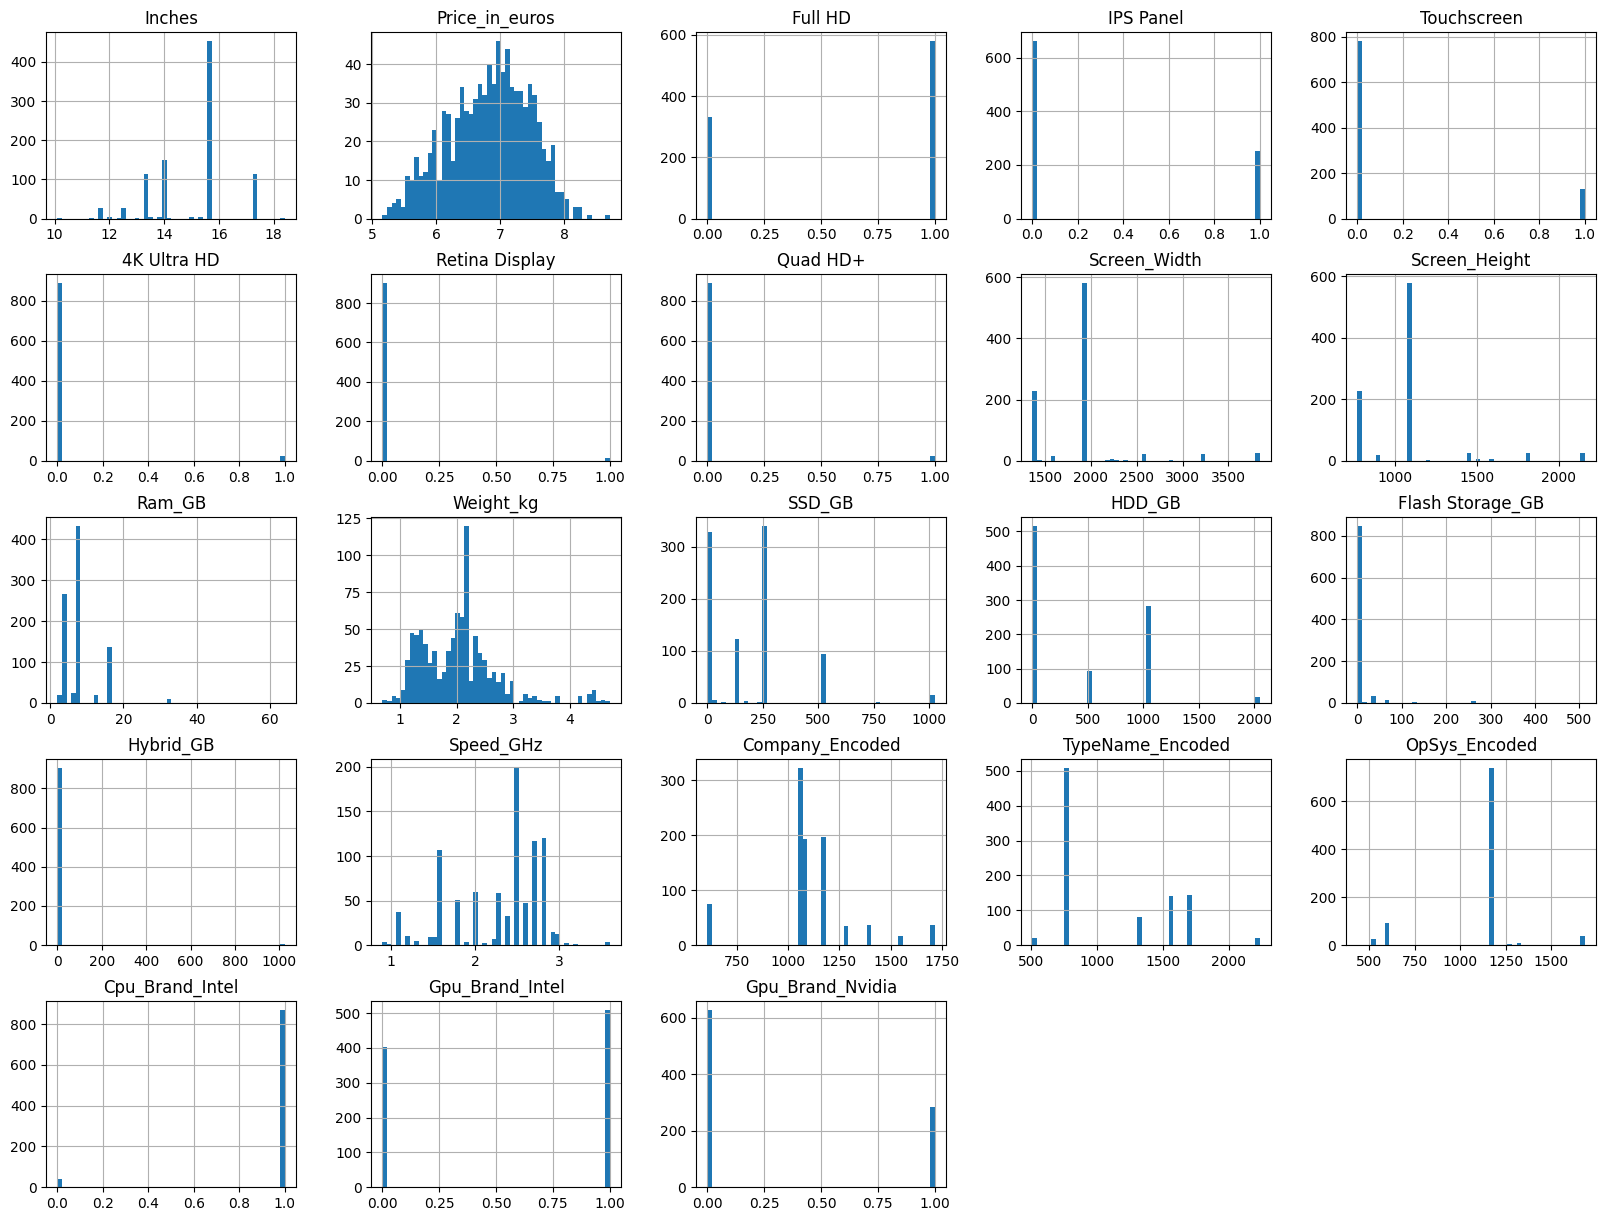

In [41]:
# Distribución de todas las features
df_copy.hist(bins=50, figsize=(20, 15))
plt.show()


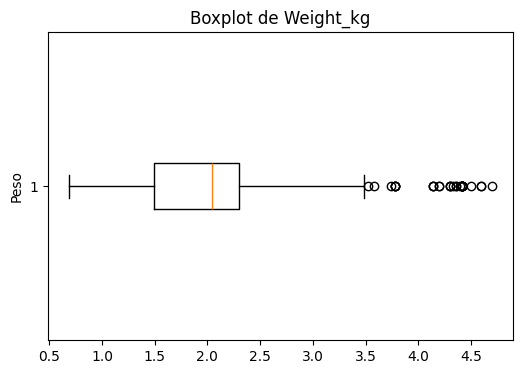

In [42]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_copy['Weight_kg'], vert=False)
plt.title('Boxplot de Weight_kg')
plt.ylabel('Peso')
plt.show()

In [43]:
df_copy["Weight_kg"] = np.log(df_copy["Weight_kg"])

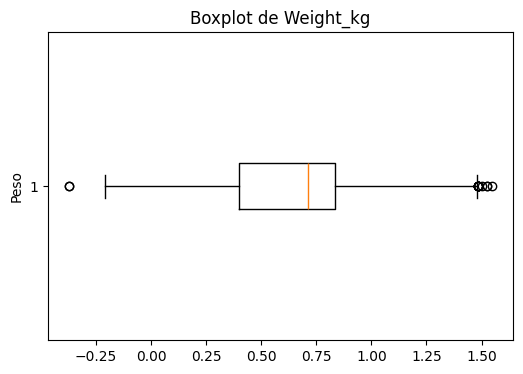

In [44]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_copy['Weight_kg'], vert=False)
plt.title('Boxplot de Weight_kg')
plt.ylabel('Peso')
plt.show()

In [45]:
# Outliers en la variable peso logaritmizada
mf.outlier_iqr(df_copy, "Weight_kg")


Outliers in Weight_kg: 
    laptop_ID  Weight_kg
0        1129  -0.371064
1         592   1.504077
2         431   1.486140
3         559   1.486140
4         537   1.486140
5         584   1.526056
6         243   1.547563
7         463   1.486140
8          51  -0.371064
9         667   1.486140
10       1062   1.526056
11        982   1.486140
12        789   1.486140
13        229   1.486140


<Axes: >

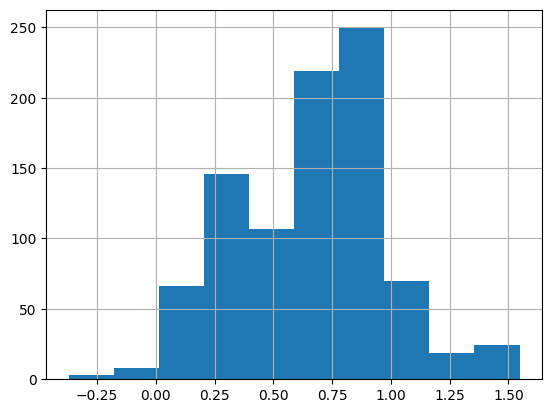

In [46]:
df_copy["Weight_kg"].hist()

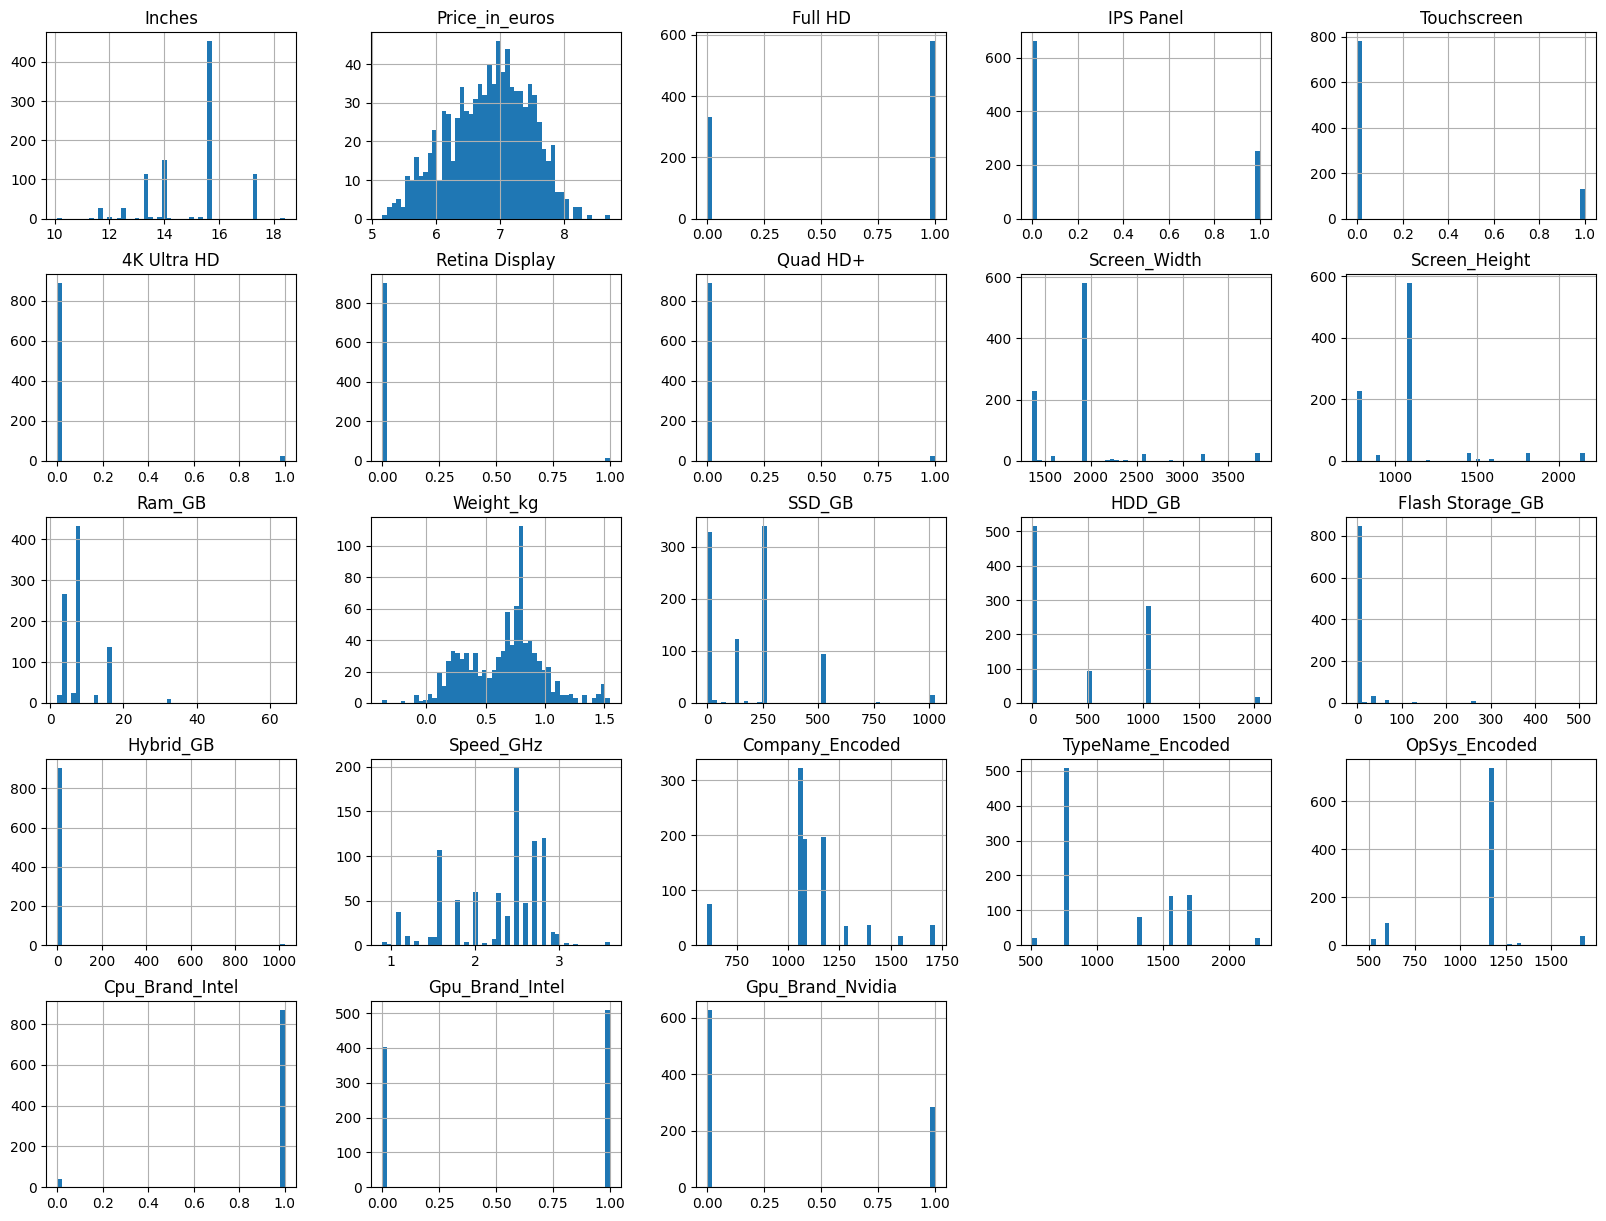

In [47]:
# Distribución de todas las features
df_copy.hist(bins=50, figsize=(20, 15))
plt.show()

In [48]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inches            912 non-null    float64
 1   Price_in_euros    912 non-null    float64
 2   Full HD           912 non-null    int64  
 3   IPS Panel         912 non-null    int64  
 4   Touchscreen       912 non-null    int64  
 5   4K Ultra HD       912 non-null    int64  
 6   Retina Display    912 non-null    int64  
 7   Quad HD+          912 non-null    int64  
 8   Screen_Width      912 non-null    int64  
 9   Screen_Height     912 non-null    int64  
 10  Ram_GB            912 non-null    int64  
 11  Weight_kg         912 non-null    float64
 12  SSD_GB            912 non-null    int64  
 13  HDD_GB            912 non-null    int64  
 14  Flash Storage_GB  912 non-null    int64  
 15  Hybrid_GB         912 non-null    int64  
 16  Speed_GHz         912 non-null    float64
 17  

In [49]:
scaler = StandardScaler()

features_scaler = ["Inches","Weight_kg","Speed_GHz"]

df_copy[features_scaler] = scaler.fit_transform(df_copy[features_scaler])

In [50]:
# Correlaciones con la variable objetivo logaritmizada
correlations = df_copy.corr()["Price_in_euros"].sort_values(ascending=False)
print(correlations)

Price_in_euros      1.000000
Ram_GB              0.679431
SSD_GB              0.652279
TypeName_Encoded    0.642807
Screen_Height       0.560624
Screen_Width        0.559601
Speed_GHz           0.508337
OpSys_Encoded       0.384871
Full HD             0.367698
Gpu_Brand_Nvidia    0.345286
Company_Encoded     0.330933
IPS Panel           0.289690
4K Ultra HD         0.224645
Cpu_Brand_Intel     0.217041
Touchscreen         0.214053
Quad HD+            0.129461
Retina Display      0.111905
Inches              0.060795
Weight_kg           0.055476
Hybrid_GB          -0.023185
Flash Storage_GB   -0.066011
HDD_GB             -0.069476
Gpu_Brand_Intel    -0.196805
Name: Price_in_euros, dtype: float64


### 2.3 Definir X e y

In [51]:
df = df_copy.copy()
    
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 22)

In [52]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [38]:
X_train

,Inches,Full HD,IPS Panel,Touchscreen,4K Ultra HD,Retina Display,Quad HD+,Screen_Width,Screen_Height,Ram_GB,...,HDD_GB,Flash Storage_GB,Hybrid_GB,Speed_GHz,Company_Encoded,TypeName_Encoded,OpSys_Encoded,Cpu_Brand_Intel,Gpu_Brand_Intel,Gpu_Brand_Nvidia
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,17.3,1,1,0,0,0,0,1920,1080,8,...,1024,0,0,2.6,1093.484639,2233.926000,1683.263448,True,False,False
153,15.6,1,0,0,0,0,0,1920,1080,16,...,0,0,0,2.8,1173.998680,1701.052238,1161.645951,True,False,True
275,13.3,0,1,0,0,1,0,2560,1600,8,...,0,0,0,2.9,1540.322353,1552.962837,1686.137273,True,True,False
1100,14.0,1,0,0,0,0,0,1920,1080,4,...,500,0,0,2.3,1093.484639,766.723674,1683.263448,True,True,False
131,17.3,1,0,0,0,0,0,1920,1080,16,...,2048,0,0,1.8,1173.998680,766.723674,1161.645951,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,14.0,0,0,0,0,0,0,1366,768,8,...,2048,0,0,1.6,1093.484639,766.723674,1161.645951,True,True,False
996,15.6,1,0,0,0,0,0,1920,1080,6,...,0,0,0,3.6,1053.578416,766.723674,1161.645951,False,False,False
770,12.5,1,0,0,0,0,0,1920,1080,16,...,0,0,0,2.8,1173.998680,1552.962837,1161.645951,True,True,False


In [39]:
y_train

laptop_ID
1118    2899.00
153     1249.26
275     1958.90
1100    1030.99
131     1396.00
         ...   
578      389.00
996      549.00
770     1859.00
407      306.00
418     1943.00
Name: Price_in_euros, Length: 729, dtype: float64

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [53]:
X_pred = pd.read_csv("./data/test.csv")
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [54]:
X_pred.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
390,421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [55]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         391 non-null    int64  
 1   Company           391 non-null    object 
 2   Product           391 non-null    object 
 3   TypeName          391 non-null    object 
 4   Inches            391 non-null    float64
 5   ScreenResolution  391 non-null    object 
 6   Cpu               391 non-null    object 
 7   Ram               391 non-null    object 
 8   Memory            391 non-null    object 
 9   Gpu               391 non-null    object 
 10  OpSys             391 non-null    object 
 11  Weight            391 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 36.8+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [56]:
X_pred

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg
...,...,...,...,...,...,...,...,...,...,...,...,...
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg


In [57]:
predictions_submit = model.predict(X_pred)
predictions_submit

NameError: name 'model' is not defined

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [ ]:
sample = pd.read_csv("data/sample_submission.csv")

In [ ]:
sample.head()

In [ ]:
sample.shape

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [ ]:
#¿Cómo creamos la submission?
submission = pd.DataFrame()

In [ ]:
submission.head()

In [ ]:
submission.shape

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [ ]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [ ]:
chequeador(submission)